# Environment Setup

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Data Loading

In [11]:
df = pd.read_csv(r'../dataset/heart_disease_uci.csv')
df.head()

,id,age,Gender,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Exploratory Data Analysis on Raw Data

### 1. Dataset Dimensions

In [257]:
df.shape

(920, 16)

### 2. Dataset Structure Overview

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   Gender    920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### 3. Feature Type Identification

In [259]:
#Identify Column Data Types
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Gender', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical columns: ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


### 4. Statistical Summary of Numerical Features

In [260]:
#df.describe(): Computes count, mean, std deviation, min/max and quartiles for numerical columns.
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### 5. Target Variable Distribution

In [261]:
df['num'].value_counts() #Target variables

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

### 6. Missing Value Count and Percentage

In [262]:
# Missing Value Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

print(missing_df)

          Missing Values  Percentage (%)
ca                   611       66.413043
thal                 486       52.826087
slope                309       33.586957
fbs                   90        9.782609
oldpeak               62        6.739130
trestbps              59        6.413043
thalch                55        5.978261
exang                 55        5.978261
chol                  30        3.260870
restecg                2        0.217391
id                     0        0.000000
age                    0        0.000000
Gender                 0        0.000000
dataset                0        0.000000
cp                     0        0.000000
num                    0        0.000000


### 7. Univariate Distribution Analysis of Numerical Features
##### (analyzes the distribution of each numerical feature to identify skewness, spread, potential outliers, and abnormal clinical patterns that may influence heart disease prediction.)

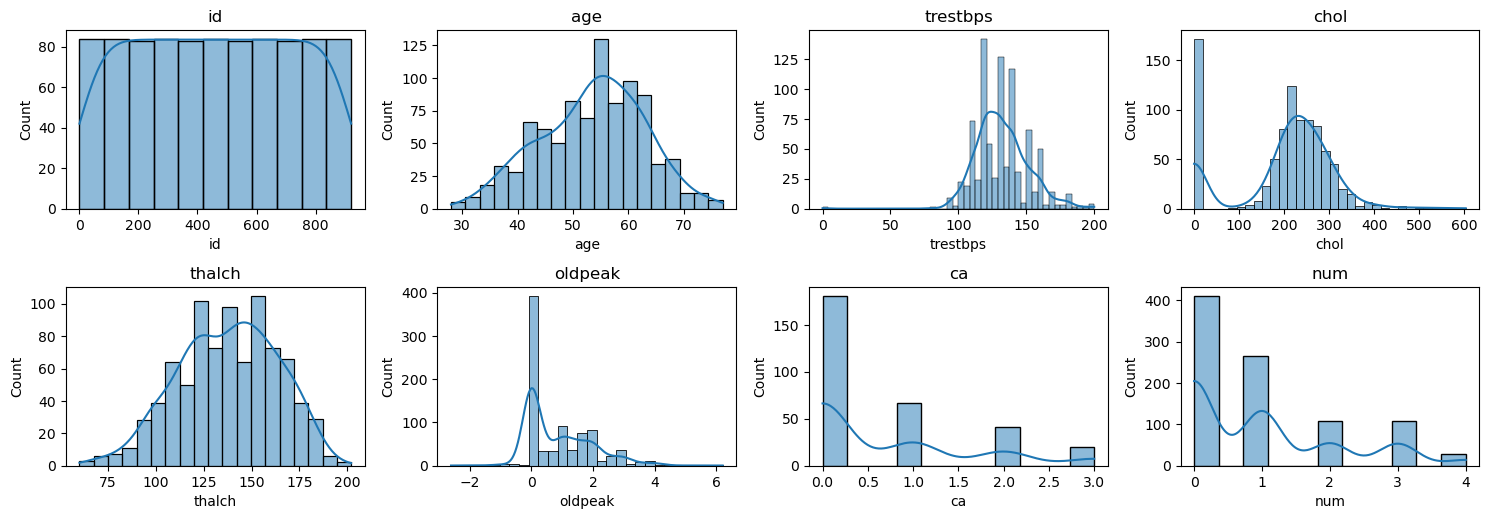

In [263]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

### 8. Outlier Analysis Using Boxplots
##### (Boxplots are used to examine the distribution, dispersion, and potential outliers of numerical features in the dataset.)

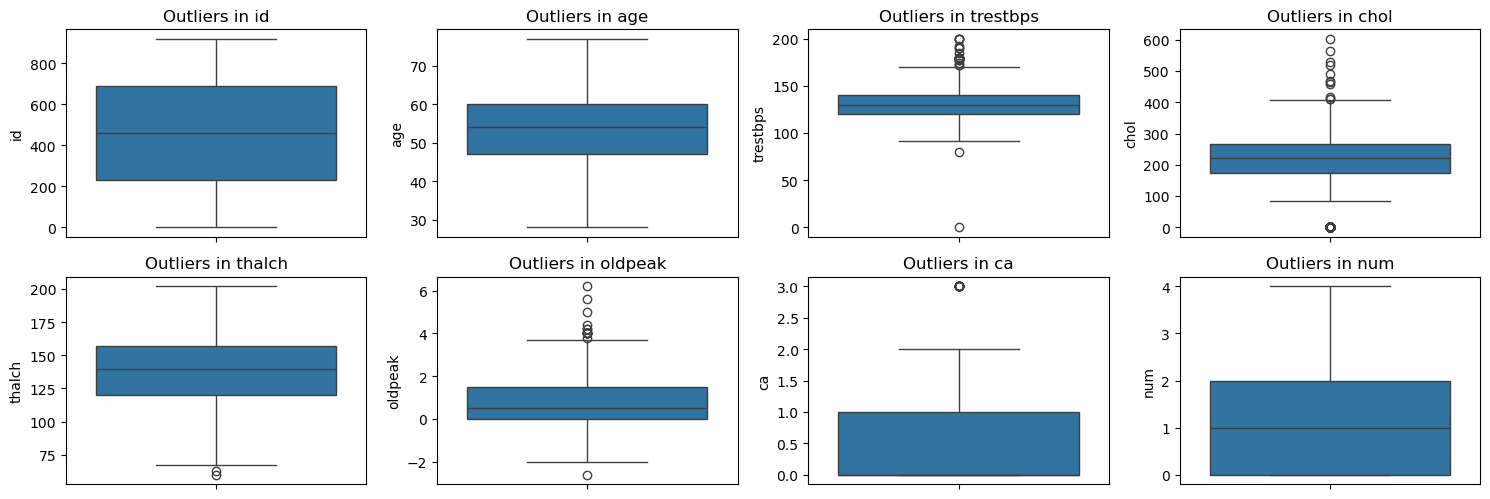

In [264]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

# Data Preprocessing

### 1. Target Variable Transformation (Multi-Class to Binary)

In [265]:
# Convert multi-class target into binary
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

### 2. Missing Value Imputation

##### Median strategy for Numerical features

In [266]:
from sklearn.impute import SimpleImputer

# Select numerical columns alone
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create imputer
imputer = SimpleImputer(strategy='median')

# Apply to all numerical columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

##### Most-Frequent Imputation for Categorical features

In [267]:
# Select Categorical columns alone
cat_cols = df.select_dtypes(include=['object']).columns

# Categorical imputation
cat_imputer = SimpleImputer(strategy='most_frequent')

# Apply to all Categorical columns
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

### 3. Remove Outliers Using the Interquartile Range (IQR) Method

(IQR = Q3 (75th percentile) − Q1 (25th percentile))  
Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are outliers.

In [268]:
# Create a copy of the dataset
df_iqr = df.copy()

# Apply IQR method column-wise
for col in numeric_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_iqr = df_iqr[
        (df_iqr[col] >= lower_bound) &
        (df_iqr[col] <= upper_bound)
    ]

df_iqr.shape

(544, 17)

In [269]:
print("Original dataset shape:", df.shape)
print("After IQR outlier removal:", df_iqr.shape)

Original dataset shape: (920, 17)
After IQR outlier removal: (544, 17)


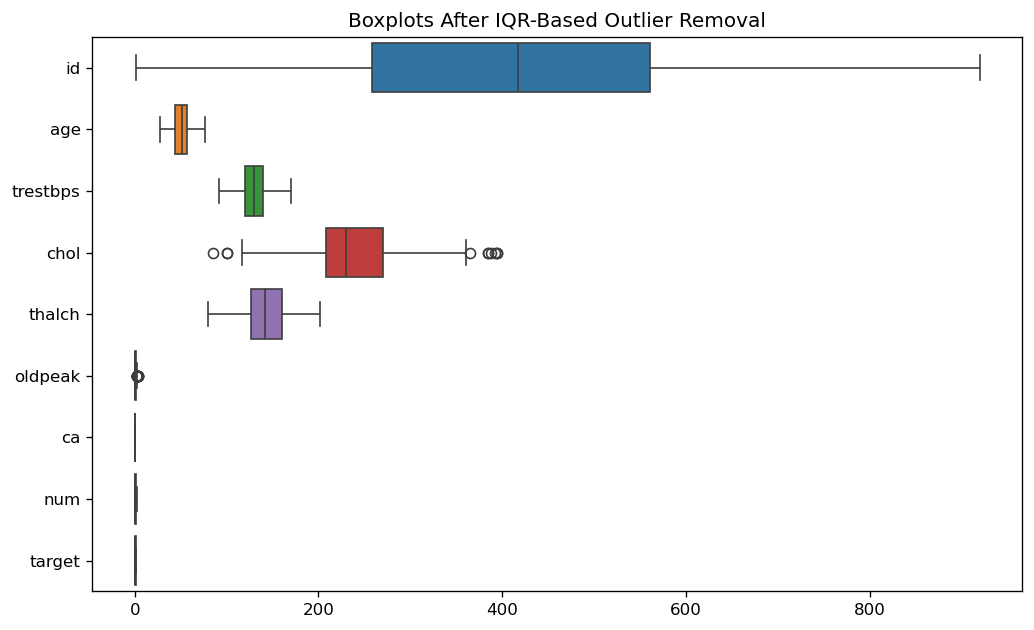

In [270]:
plt.figure(figsize=(10, 6), dpi=120)
sns.boxplot(data=df_iqr[numeric_cols], orient='h')
plt.title("Boxplots After IQR-Based Outlier Removal")
plt.show()

# Post-Cleaning EDA

### 1. Visualize Target Variable Distribution
##### Check if target classes (Disease vs No Disease) are balanced, affecting model training and evaluation.

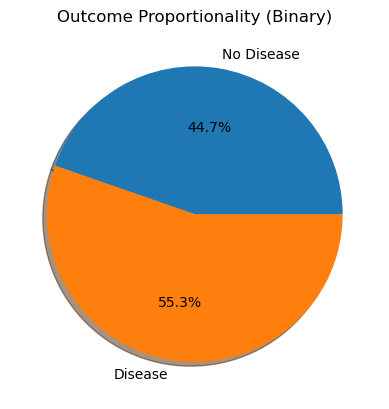

In [271]:
# Count binary classes
counts = df['target'].value_counts()

# Ensure correct order (0 = No Disease, 1 = Disease)
counts = counts.sort_index()

plt.pie(
    counts,
    labels=['No Disease', 'Disease'],
    autopct='%.1f%%',
    shadow=True
)

plt.title('Outcome Proportionality (Binary)')
plt.show()

### 2. Correlation Analysis
##### To understand relationships between features and the target variable (Outcome).

In [272]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_df.corr()

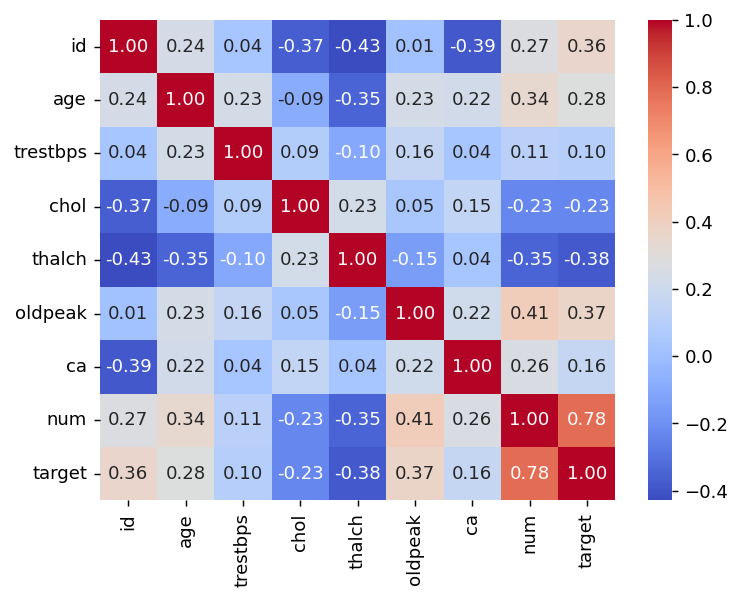

In [273]:
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### 3. Feature–Target Correlation Analysis

##### Numerical features are ranked based on their correlation with the target variable to assess predictive relevance.

In [274]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation with orrect target column
correlation_with_target = (
    numeric_df.corr()['num']
    .drop('num')
    .sort_values(ascending=False)
)

print("Correlation of Numerical Features with Target:")
print(correlation_with_target)

Correlation of Numerical Features with Target:
target      0.783387
oldpeak     0.411588
age         0.339596
id          0.273552
ca          0.261797
trestbps    0.113178
chol       -0.230539
thalch     -0.349173
Name: num, dtype: float64


### 4. Bivariate Analysis: Numerical Features vs Target

##### Compares numerical features across heart disease classes to identify discriminative patterns and clinically meaningful differences.

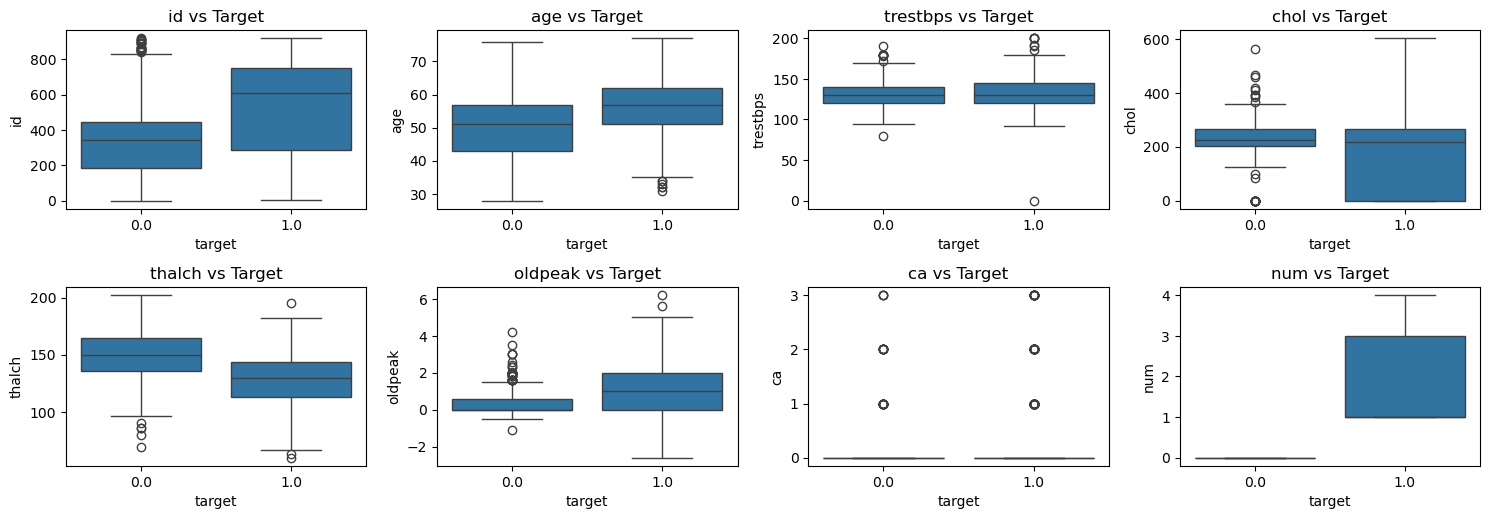

In [275]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x=df['target'], y=df[col])
    plt.title(f"{col} vs Target")

plt.tight_layout()
plt.show()

# Feature Scaling

In [276]:
X = df.drop('num', axis=1)
y = df['num']

In [277]:
X['Gender'] = X['Gender'].astype(str).str.strip().str.lower()

In [278]:
X['Gender'] = X['Gender'].map({'male': 1, 'female': 0})

In [279]:
X.isnull().sum()

id          0
age         0
Gender      0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### 1. Normalization (Min-Max)
#### rescales features to a common range (0 to 1)

In [280]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Step 1: Separate features and target
X = df.drop(columns=['num'])   # 'num' is your target
y = df['num']

# Step 2: Convert categorical columns using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 3: Apply MinMaxScaler
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_encoded)

# Convert back to DataFrame (important for compatibility)
X_normalized = pd.DataFrame(X_normalized, columns=X_encoded.columns)

print(X_normalized.head())

         id       age  trestbps      chol    thalch   oldpeak        ca  \
0  0.000000  0.714286     0.725  0.386401  0.633803  0.556818  0.000000   
1  0.001088  0.795918     0.800  0.474295  0.338028  0.465909  1.000000   
2  0.002176  0.795918     0.600  0.379768  0.485915  0.590909  0.666667   
3  0.003264  0.183673     0.650  0.414594  0.894366  0.693182  0.000000   
4  0.004353  0.265306     0.650  0.338308  0.788732  0.454545  0.000000   

   target  Gender_Male  dataset_Hungary  ...  cp_non-anginal  \
0     0.0          1.0              0.0  ...             0.0   
1     1.0          1.0              0.0  ...             0.0   
2     1.0          1.0              0.0  ...             0.0   
3     0.0          1.0              0.0  ...             1.0   
4     0.0          0.0              0.0  ...             0.0   

   cp_typical angina  fbs_True  restecg_normal  restecg_st-t abnormality  \
0                1.0       1.0             0.0                       0.0   
1           

### 2. Standardization
#### rescales features so they have mean 0 and standard deviation 1

In [281]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# One-Hot Encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Apply StandardScaler
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_encoded)

# Convert back to DataFrame (VERY IMPORTANT for compatibility)
X_standardized = pd.DataFrame(
    X_standardized,
    columns=X_encoded.columns
)

print(X_standardized.head())

         id       age  trestbps      chol    thalch   oldpeak        ca  \
0 -1.730169  1.007386  0.705176  0.303643  0.489727  1.368109 -0.361400   
1 -1.726404  1.432034  1.518569  0.789967 -1.181478  0.611589  4.411152   
2 -1.722639  1.432034 -0.650479  0.266939 -0.345875  1.651804  2.820301   
3 -1.718873 -1.752828 -0.108217  0.459634  1.961979  2.502889 -0.361400   
4 -1.715108 -1.328180 -0.108217  0.037541  1.365120  0.517024 -0.361400   

     target  Gender_Male  dataset_Hungary  ...  cp_non-anginal  \
0 -1.112853     0.516931        -0.683597  ...       -0.533775   
1  0.898591     0.516931        -0.683597  ...       -0.533775   
2  0.898591     0.516931        -0.683597  ...       -0.533775   
3 -1.112853     0.516931        -0.683597  ...        1.873447   
4 -1.112853    -1.934494        -0.683597  ...       -0.533775   

   cp_typical angina  fbs_True  restecg_normal  restecg_st-t abnormality  \
0           4.358899  2.380476       -1.227523                 -0.491493   


# Train–Test Split

In [282]:
X = df.drop(columns=['num', 'target'])
y = df['target']

In [283]:
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

In [284]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Handle Class Imbalance Using SMOTE
##### To balance minority and majority classes in the training data only.

In [285]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()

# Scale AFTER splitting
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("After SMOTE shape:", X_train_resampled.shape)

After SMOTE shape: (814, 22)


# Model Development and Training

#### 1. Support Vector Machine (SVM)
##### To build a strong margin-based classifier suitable for medical diagnosis.

In [286]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_resampled, y_train_resampled)

y_pred_svm = svm.predict(X_test_scaled)

### 2. Random Forest Classifier
##### To model non-linear feature interactions using ensemble learning.

In [287]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42,class_weight='balanced')

param_grid = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=25,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_resampled, y_train_resampled)

best_rf = rf_random.best_estimator_
print("Best RF Parameters:", rf_random.best_params_)

# Generate predictions using BEST tuned model
y_pred_rf = best_rf.predict(X_test_scaled)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}


### 3. XGBoost Classifier
##### To leverage gradient boosting for high predictive accuracy.

In [288]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, accuracy_score, classification_report, confusion_matrix

xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss'
)

param_grid_xgb = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#  Step 1: Hyperparameter tuning (training phase)
xgb_random.fit(X_train_resampled, y_train_resampled)

best_xgb = xgb_random.best_estimator_
print("Best XGB Parameters:", xgb_random.best_params_)

#  Step 2: Get probability predictions (test phase)
y_probs_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

#  Step 3: Threshold optimization using ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

#  Step 4: Apply optimized threshold
y_pred_xgb = (y_probs_xgb >= optimal_threshold).astype(int)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Optimal Threshold: 0.31144223


### 4. LightGBM Classifier
##### To build a fast and efficient gradient boosting model.

In [289]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=100,        # reduced
    learning_rate=0.1,       # slightly higher
    max_depth=3,             # shallower trees
    min_child_samples=20,    # prevents useless splits
    random_state=42,
    verbose=-1               # suppress warnings
)

lgbm.fit(X_train_resampled, y_train_resampled)

y_pred_lgbm = lgbm.predict(X_test_scaled)
y_prob_lgbm = lgbm.predict_proba(X_test_scaled)[:, 1]

# Model Evalaution

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### 1. SVM


SVM
Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

         0.0       0.90      0.79      0.84        82
         1.0       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



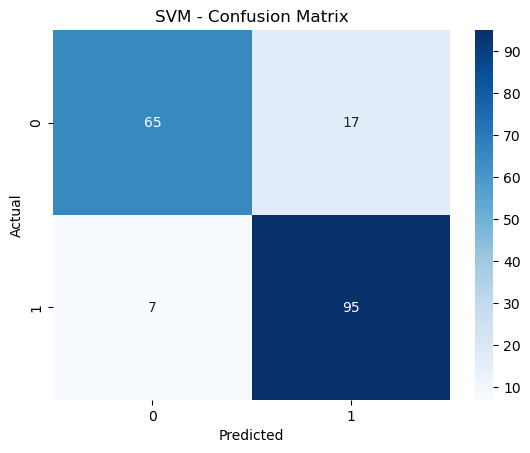

In [291]:
evaluate_model(y_test, y_pred_svm, "SVM")

### 2. Random Forest


Random Forest
Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

         0.0       0.90      0.79      0.84        82
         1.0       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



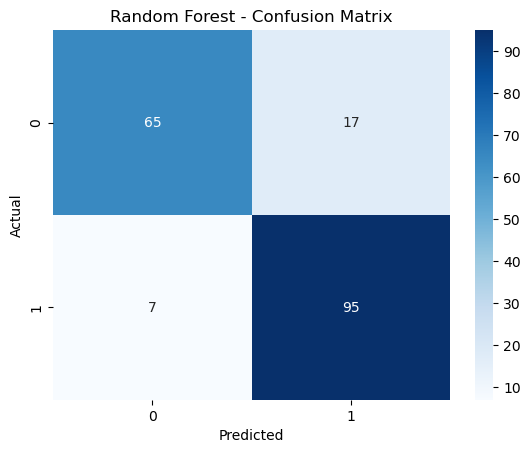

In [292]:
evaluate_model(y_test, y_pred_rf, "Random Forest")

### 3. XGBoost


XGBoost
Accuracy: 0.9021739130434783
              precision    recall  f1-score   support

         0.0       0.96      0.82      0.88        82
         1.0       0.87      0.97      0.92       102

    accuracy                           0.90       184
   macro avg       0.91      0.89      0.90       184
weighted avg       0.91      0.90      0.90       184



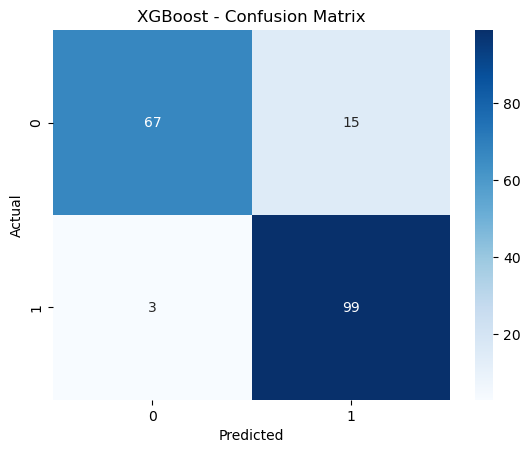

In [293]:
evaluate_model(y_test, y_pred_xgb, "XGBoost")

### 4. LightGBM


LightGBM
Accuracy: 0.8858695652173914
              precision    recall  f1-score   support

         0.0       0.91      0.83      0.87        82
         1.0       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



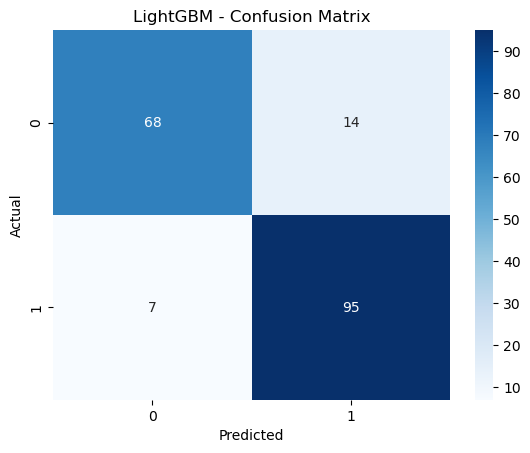

In [294]:
evaluate_model(y_test, y_pred_lgbm, "LightGBM")

# Performance Comparison

##### Probability Score Generation for ROC and AUC Analysis

In [295]:
# Generate Probability Scores for ROC Analysis

# SVM 
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

# Random Forest 
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# XGBoost
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

# LightGBM
y_prob_lgbm = lgbm.predict_proba(X_test_scaled)[:, 1]

### 1. ROC Curve and AUC Comparison Across Models

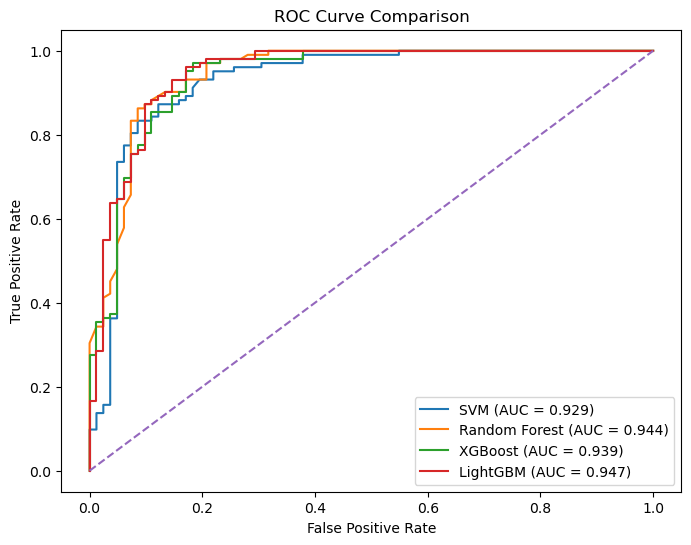

In [296]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models_probs = {
    "SVM": y_prob_svm,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "LightGBM": y_prob_lgbm
}

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### 2. Precision–Recall Curve Comparison

##### Used to assess model effectiveness under class imbalance, highlighting the trade-off between recall (sensitivity) and precision.

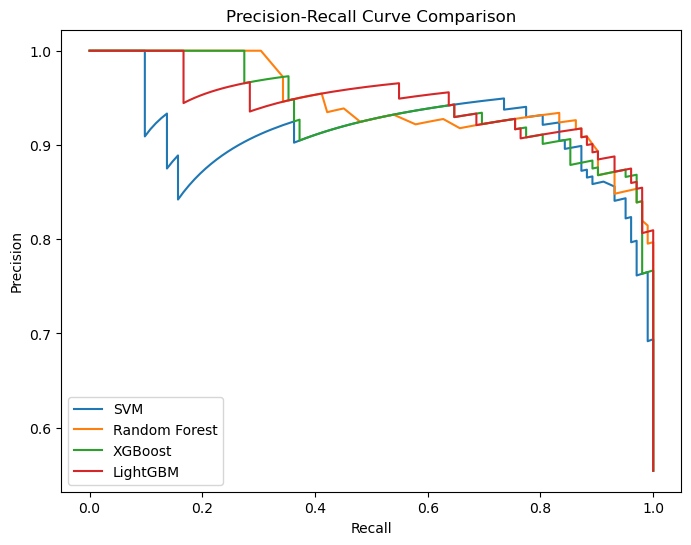

In [297]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

#### 3. Comparative Performance Evaluation of All Models
##### sorted by F1 Score to identify the model with the best overall classification balance

In [298]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#  Create predictions dictionary using YOUR existing variables
models_predictions = {
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm
}

results = []

for name, preds in models_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost,0.902174,0.868421,0.970588,0.916667
3,LightGBM,0.885870,0.871560,0.931373,0.900474
0,SVM,0.869565,0.848214,0.931373,0.887850
1,Random Forest,0.869565,0.848214,0.931373,0.887850
